In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
import itertools

In [2]:
file_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/two_class_raw_3s_yo_0.8.csv'
features = pd.read_csv(file_path)
features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

In [3]:
class_names = ['void', 'non-void']

In [4]:
def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap())
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        plt.text(j, i, format(cnf_matrix[i, j], fmt), horizontalalignment="center",
                color="black" if cnf_matrix[i, j] > thresh else "yellow")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix

In [5]:
def plot_confusion_matrix(predicted_labels_list, y_test_list, strategy_name, exp_name):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list, labels=class_names)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title=f'DecisionTree - {exp_name}({strategy_name})')
    file_name = f'cv-cm_{exp_name}_{strategy_name}.png'
    plt.savefig(f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/XGBoost/2_class/cv-conf-mat/{file_name}')
    plt.show()

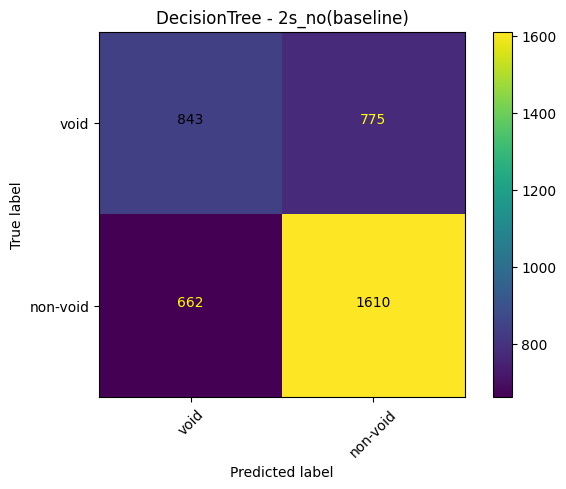

In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]



# Cross-validation setup
gkf = GroupKFold(n_splits=10) 
fold_results = []
        
# For confusion matrix
predicted_targets = np.array([])
actual_targets = np.array([])
        
for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test_fold = X.iloc[train_idx_fold], X.iloc[test_idx_fold]
    y_train_fold, y_test_fold = y.iloc[train_idx_fold], y.iloc[test_idx_fold]
# for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X_train, y_train, groups_train)):   
#     X_train_fold, X_test_fold = X_train.iloc[train_idx_fold], X_train.iloc[test_idx_fold]
#     y_train_fold, y_test_fold = y_train.iloc[train_idx_fold], y_train.iloc[test_idx_fold]
    
    # sampler =  SMOTETomek(random_state=42)
    # X_train_fold, y_train_fold = sampler.fit_resample(X_train_fold, y_train_fold)
    
    # Use XGBoost with DEFAULT parameters
    model = DecisionTreeClassifier(
        random_state=42
    )
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    
    # Fit model
    model.fit(X_train_fold, y_train_encoded)
    
    # Predict
    predictions = label_encoder.inverse_transform(model.predict(X_test_fold))
    
    # For confusion matrix
    predicted_targets = np.append(predicted_targets, predictions)
    actual_targets = np.append(actual_targets, y_test_fold)
plot_confusion_matrix(predicted_targets, actual_targets,'baseline', '2s_no')

In [7]:
class_report = classification_report(actual_targets,predicted_targets, labels=class_names)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

        void       0.56      0.52      0.54      1618
    non-void       0.68      0.71      0.69      2272

    accuracy                           0.63      3890
   macro avg       0.62      0.61      0.62      3890
weighted avg       0.63      0.63      0.63      3890



### Test

I wish 🤣

In [8]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test))
report = classification_report(y_test, y_pred, labels=class_names)

print(report)

              precision    recall  f1-score   support

        void       0.94      0.92      0.93       412
    non-void       0.95      0.96      0.95       629

    accuracy                           0.94      1041
   macro avg       0.94      0.94      0.94      1041
weighted avg       0.94      0.94      0.94      1041



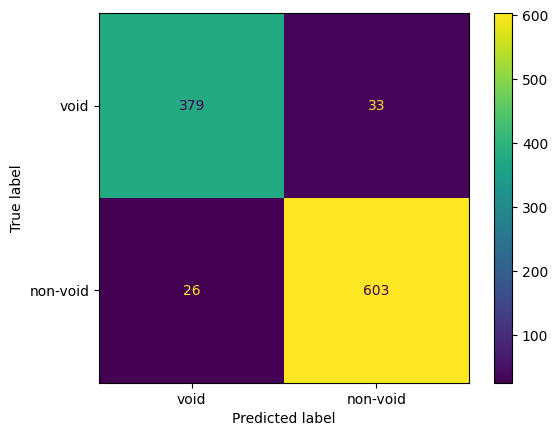

In [9]:
cnf_matrix = confusion_matrix(y_test, y_pred, labels=class_names)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cnf_matrix, display_labels = ['void', 'non-void'])
cm_display.plot()
plt.show()

In [10]:
features

,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_spectral_centroid,gyr_mag_spectral_spread,gyr_mag_spectral_flatness,gyr_mag_peak_frequency_ratio,gyr_mag_hjorth_frequency,gyr_mag_spectral_skewness,gyr_mag_spectral_kurtosis,gyr_mag_snr,label,experiment_id
0,0.868352,0.694367,0.953067,0.839825,5.349532,1.270292,0.705305,-1.100002,4.249530,285.614550,...,2.461041,2.506423,0.022774,0.266252,7.726912,1.861881,9.498110,-4.402532,non-void,1
1,0.891024,0.700772,0.937189,0.752365,5.349532,1.201822,0.566053,-1.100002,4.249530,255.654427,...,1.583183,2.266877,0.029356,0.478029,8.301187,3.869287,28.466800,-0.381925,non-void,1
2,0.904307,0.779004,0.836695,0.516392,3.553001,0.983219,0.266661,-0.289933,3.263068,171.109478,...,1.705613,3.568219,0.069833,0.698554,8.725039,3.870708,20.551180,3.649895,non-void,1
3,0.900103,0.797495,0.724808,0.273863,1.507445,0.774821,0.075001,-0.158125,1.349320,106.261539,...,3.262713,4.221081,0.117658,0.202735,11.859443,2.446862,10.084393,-5.946738,non-void,1
4,0.917587,0.797179,0.654555,0.289030,1.550907,0.715528,0.083538,-0.201588,1.349320,90.620560,...,3.877225,4.234889,0.138326,0.115002,11.831409,1.860618,6.621215,-8.862387,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3885,0.899544,0.886632,-0.449663,0.154201,0.691288,0.475368,0.023778,-0.799493,-0.108205,40.901411,...,3.131630,4.625019,0.121297,0.182096,13.534647,2.504941,9.171879,-6.524008,non-void,41
3886,0.919431,0.886939,-0.389008,0.166484,0.758337,0.423136,0.027717,-0.799493,-0.041157,32.406919,...,2.676275,3.993931,0.097056,0.205798,13.522834,2.912652,12.516709,-5.864899,non-void,41
3887,0.921653,0.877697,-0.325674,0.148317,0.758337,0.357857,0.021998,-0.799493,-0.041157,23.179124,...,3.705396,5.377850,0.181513,0.212583,13.143879,2.246887,8.098158,-5.686768,non-void,41
3888,0.934054,0.832424,-0.289582,0.108687,0.538564,0.309306,0.011813,-0.579721,-0.041157,17.316359,...,5.745091,6.479683,0.258383,0.247429,13.072300,1.498011,4.837061,-4.830964,non-void,41


In [11]:
labels = features['label']
print(f'total = {len(labels)}')
print(f'void = {len(labels[labels == 'void'])}')
print(f'non-void = {len(labels[labels == 'non-void'])}')

total = 3890
void = 1618
non-void = 2272
